# Country-Level Longer-Term Forecasting of First-Time Asylum Applications

*A time-series analysis and forecasting exercise using Italy monthly Eurostat data*

This notebook uses monthly first-time asylum application data for Italy to demonstrate a longer-term country-level forecasting workflow.

The purpose is demonstrative and illustrative. The notebook is not an operational forecast product, and it does not attempt to explain the full political, legal, administrative, or structural dynamics behind asylum applications in Italy. Instead, it shows how a real administrative time series can be prepared, explored, split into training and test periods, modelled with transparent time-series methods, and interpreted with appropriate caution.

The target series is **monthly first-time asylum applications**. This brings in some caveats. Asylum applications are administrative events. They are not the same as regular or irregular entries, border arrivals, total displacement movements, or the number of people in need of protection at any given time. First-time applications may be affected by access to the asylum procedure, border management, administrative capacity, policy changes, onward movement, and wider dynamics in a country's asylum system or in countries of origin. They may also be affected by changes in the legal circumstances of certain individuals or groups of people.

For that reason, the forecasts in this notebook should be read as model-based projections of an administrative series, not as direct predictions of future arrivals or the volume of international protection needs.

# Part I - Understanding the time series

## 1. Setup


In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


## 2. Load prepared monthly series

The public notebook uses a cleaned monthly CSV derived from a locally downloaded Eurostat Excel file.

The original Excel file had countries as rows and monthly values as columns, with monthly date columns alternating with status or blank columns. During preparation, the Italy row was selected, monthly columns were parsed, Eurostat missing markers were converted, and incomplete months were excluded.

The modelling series used here runs from **January 2008 to February 2026**. The incomplete months **March 2026** and **April 2026** are not imputed and are not included.


In [41]:
data_path_candidates = [
    Path("data/processed/italy_first_time_asylum_monthly.csv"),
    Path("../../data/processed/italy_first_time_asylum_monthly.csv"),
]
data_path = next(path for path in data_path_candidates if path.exists())

applications = (
    pd.read_csv(data_path, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

applications_display = applications.rename(
    columns={"date": "Month", "applications": "First-time applications"}
)
applications_display.head()


,Month,First-time applications
0,2008-01-01,1170
1,2008-02-01,1105
2,2008-03-01,1800
3,2008-04-01,1780
4,2008-05-01,2850


In [42]:
applications_display.tail()


,Month,First-time applications
213,2025-10-01,12650
214,2025-11-01,12195
215,2025-12-01,9985
216,2026-01-01,10660
217,2026-02-01,10560


Before plotting the series, we check the basic structure of the data.


In [43]:
summary_table = pd.DataFrame(
    {
        "Measure": [
            "Start date",
            "End date",
            "Number of months",
            "Total applications",
            "Mean monthly applications",
            "Median monthly applications",
            "Minimum monthly applications",
            "Maximum monthly applications",
            "Missing values",
        ],
        "Value": [
            applications["date"].min().strftime("%B %Y"),
            applications["date"].max().strftime("%B %Y"),
            len(applications),
            f"{applications['applications'].sum():,.0f}",
            f"{applications['applications'].mean():,.1f}",
            f"{applications['applications'].median():,.1f}",
            f"{applications['applications'].min():,.0f}",
            f"{applications['applications'].max():,.0f}",
            int(applications.isna().sum().sum()),
        ],
    }
)

summary_table


,Measure,Value
0,Start date,January 2008
1,End date,February 2026
2,Number of months,218
3,Total applications,"1,196,610"
4,Mean monthly applications,"5,489.0"
5,Median monthly applications,"4,147.5"
6,Minimum monthly applications,120
7,Maximum monthly applications,"15,115"
8,Missing values,0


The series contains monthly counts of first-time asylum applications in Italy. The values are non-negative integer counts. The date range and missing-value checks confirm that the processed file is ready for exploratory time-series analysis.

## 3. Exploratory time-series analysis

We start by plotting the raw monthly series.


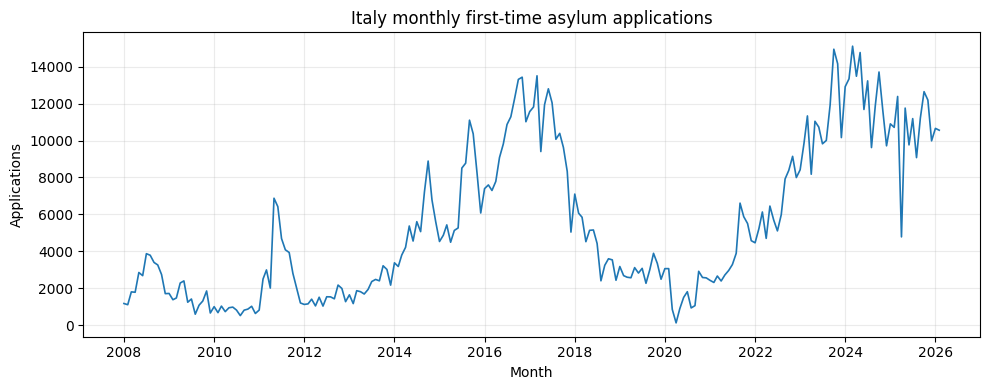

In [44]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    applications["date"],
    applications["applications"],
    linewidth=1.2,
)
ax.set_title("Italy monthly first-time asylum applications")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.grid(alpha=0.25)
fig.tight_layout()


The raw series shows substantial variation over time. Some periods have relatively low monthly application counts, while others show much higher pressure. This is expected for an asylum application series: the observed counts can respond to conflict dynamics, route dynamics, access to territory and procedures, policy changes, registration practices, and administrative capacity.

The raw monthly pattern is useful, but it is also noisy. To make the longer movement easier to see, we add a 12-month rolling average.


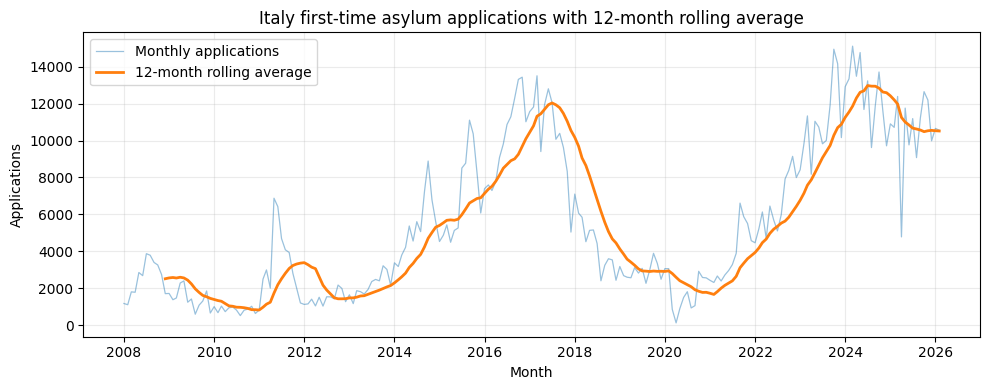

In [45]:
applications_with_rolling = applications.assign(
    rolling_12_month_average=applications["applications"].rolling(12).mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    applications_with_rolling["date"],
    applications_with_rolling["applications"],
    linewidth=0.9,
    alpha=0.45,
    label="Monthly applications",
)
ax.plot(
    applications_with_rolling["date"],
    applications_with_rolling["rolling_12_month_average"],
    linewidth=2.0,
    label="12-month rolling average",
)
ax.set_title("Italy first-time asylum applications with 12-month rolling average")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()


The 12-month rolling average smooths short-term month-to-month variation and makes broader phases more visible. It does not remove the underlying uncertainty or explain the causes of change. It simply helps separate longer movements from monthly fluctuation.

For an annual view, we aggregate the monthly counts by calendar year.


In [46]:
annual_applications = (
    applications.assign(year=applications["date"].dt.year)
    .groupby("year", as_index=False)["applications"]
    .sum()
    .rename(columns={"year": "Year", "applications": "Total applications"})
)

annual_applications


,Year,Total applications
0,2008,30140
1,2009,17370
2,2010,10005
3,2011,40300
4,2012,17170
5,2013,25725
6,2014,63660
7,2015,82790
8,2016,121190
9,2017,126550


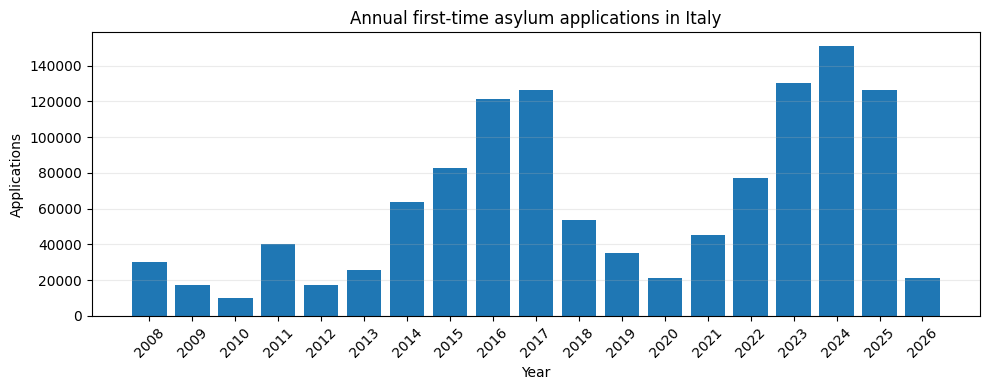

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    annual_applications["Year"].astype(str),
    annual_applications["Total applications"],
)
ax.set_title("Annual first-time asylum applications in Italy")
ax.set_xlabel("Year")
ax.set_ylabel("Applications")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()


The annual summary gives a clearer sense of scale. It also shows why a simple average is unlikely to be enough for forecasting. The series includes quieter years, higher-pressure years, and periods where the level changes substantially.

At this stage, the main lesson is descriptive: the series is not stable around one constant level. This is why the rest of the notebook moves from exploration to model-based forecasting. We will first compare simple baseline forecasts, then fit SARIMA models that account for time dependence and seasonality, and finally test whether a SARIMAX model with descriptive exogenous event-period indicators adds value.

Before doing that, we need an evaluation design. In forecasting, it is not enough to fit a model to all available observations and inspect how well it describes the past. We need to ask whether the model can make useful predictions for observations it has not seen. The next part therefore defines a training period and a test period. The training period will be used to inspect the time-series structure and fit the models; the test period will be held back so that the baselines, SARIMA models, and SARIMAX model can be evaluated against later observations.


# Part II - Creating an evaluation framework


## 4. Train/test split

The previous section showed that the application series is not stable around one constant level. The next step is to move from description to forecasting.

Before fitting models, we need an evaluation design. In a time-series setting, this means separating earlier observations from later observations. The earlier period is used for inspection and model fitting. The later period is held back and treated as future data.

This notebook uses a chronological train/test split:

- training period: January 2008 to February 2023;
- test period: March 2023 to February 2026.

The test period covers 36 months, or three full seasonal cycles. This gives us a held-out period for comparing simple baselines, SARIMA models, and later SARIMAX models against observations that were not used during fitting.


In [48]:
train_start = pd.Timestamp("2008-01-01")
train_end = pd.Timestamp("2023-02-01")
test_start = pd.Timestamp("2023-03-01")
test_end = pd.Timestamp("2026-02-01")

train = applications.loc[
    applications["date"].between(train_start, train_end)
].copy()
test = applications.loc[
    applications["date"].between(test_start, test_end)
].copy()

assert train["date"].min() == train_start
assert train["date"].max() == train_end
assert test["date"].min() == test_start
assert test["date"].max() == test_end
assert len(test) == 36

split_summary = pd.DataFrame(
    {
        "Period": ["Training", "Test"],
        "Start": [
            train["date"].min().strftime("%Y-%m"),
            test["date"].min().strftime("%Y-%m"),
        ],
        "End": [
            train["date"].max().strftime("%Y-%m"),
            test["date"].max().strftime("%Y-%m"),
        ],
        "Number of months": [len(train), len(test)],
        "Total applications": [
            int(train["applications"].sum()),
            int(test["applications"].sum()),
        ],
        "Mean monthly applications": [
            round(train["applications"].mean(), 1),
            round(test["applications"].mean(), 1),
        ],
    }
)

split_summary


,Period,Start,End,Number of months,Total applications,Mean monthly applications
0,Training,2008-01,2023-02,182,785325,4315.0
1,Test,2023-03,2026-02,36,411285,11424.6


The split is shown visually below. The vertical line marks the boundary between the training period and the held-out test period.


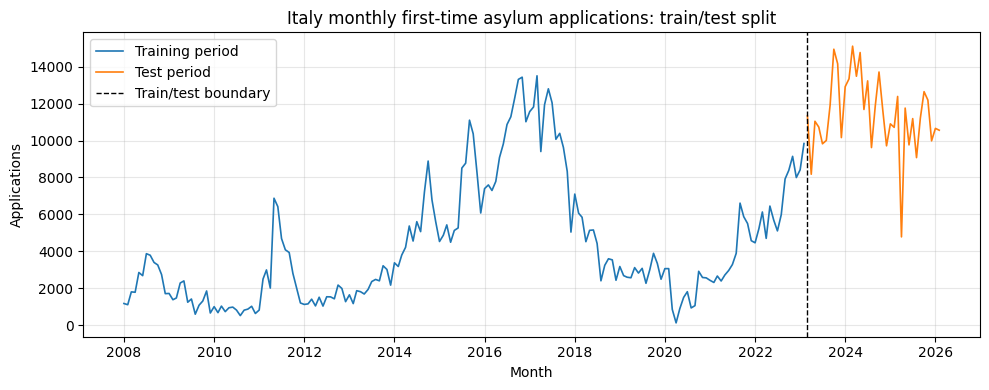

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    train["date"],
    train["applications"],
    label="Training period",
    linewidth=1.2,
)
ax.plot(
    test["date"],
    test["applications"],
    label="Test period",
    linewidth=1.2,
)
ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Train/test boundary",
)
ax.set_title("Italy monthly first-time asylum applications: train/test split")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Seasonal decomposition on the training data only

Before fitting forecasting models, it is useful to inspect the structure of the training series.

Seasonal decomposition separates a time series into three broad components:

- a trend component, which shows slower-moving changes in the level of the series;
- a seasonal component, which shows recurring within-year patterns;
- a residual or irregular component, which is what remains after the trend and seasonal pattern are removed.

The decomposition below is run on the training data only. This is important: the test period is supposed to represent future observations, so it should not be used to inspect or tune the model before evaluation.

The decomposition is descriptive. It is not yet a forecast model.


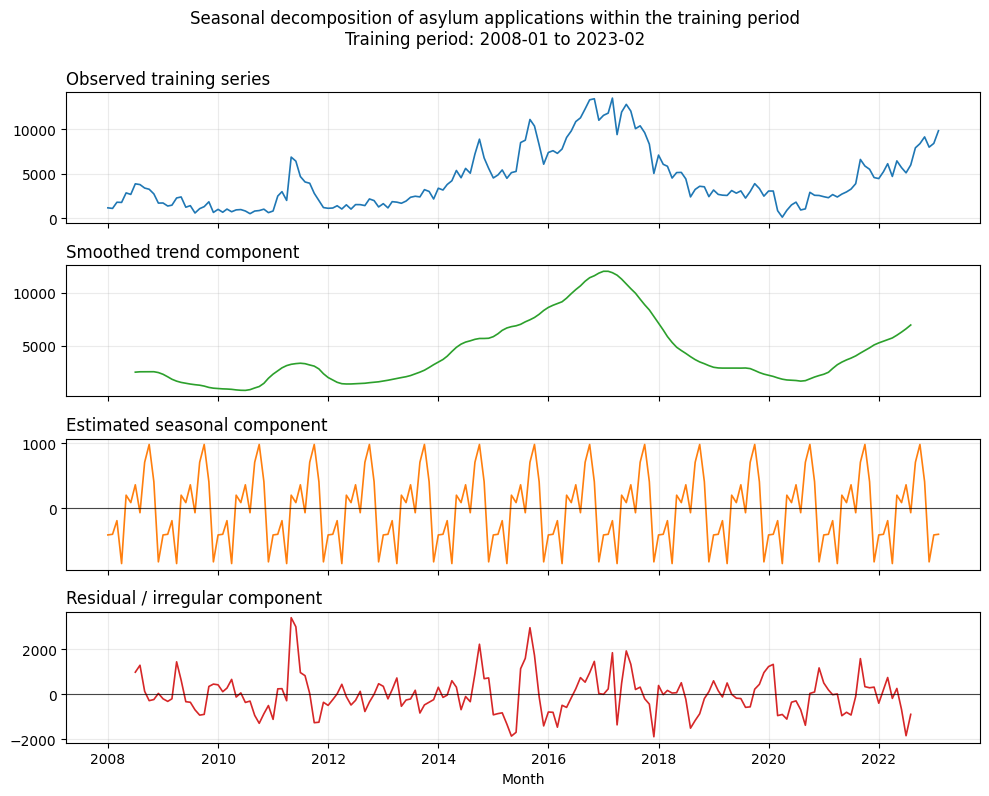

In [50]:
training_series = train.set_index("date")["applications"].asfreq("MS")

decomposition = seasonal_decompose(
    training_series,
    model="additive",
    period=12,
)

decomposition_df = pd.DataFrame(
    {
        "observed": decomposition.observed,
        "trend": decomposition.trend,
        "seasonal": decomposition.seasonal,
        "residual": decomposition.resid,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
fig.suptitle(
    "Seasonal decomposition of asylum applications within the training period\n"
    "Training period: 2008-01 to 2023-02",
    y=0.99,
)

components = [
    ("observed", "Observed training series", "#1f77b4"),
    ("trend", "Smoothed trend component", "#2ca02c"),
    ("seasonal", "Estimated seasonal component", "#ff7f0e"),
    ("residual", "Residual / irregular component", "#d62728"),
]

for ax, (column, title, color) in zip(axes, components):
    ax.plot(
        decomposition_df.index,
        decomposition_df[column],
        color=color,
        linewidth=1.2,
    )
    ax.set_title(title, loc="left")
    ax.grid(alpha=0.25)

axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.7)
axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.7)
axes[-1].set_xlabel("Month")
fig.tight_layout()
plt.show()


The decomposition gives a useful first view of the training series, but it should be interpreted cautiously.

The trend component shows large changes in the underlying level of applications over time. It is relatively low in the early years, rises substantially through the mid-2010s, reaches its highest level around 2016-2017, then declines before rising again toward the end of the training period. This confirms that the training series is not stable around one long-term average.

A recurring seasonal pattern is visible. The seasonal component suggests that some months tend to sit above or below the average within a year. This may be consistent with seasonal route, mobility, access, or administrative patterns, but the decomposition itself does not identify the cause. It only shows that recurring within-year variation is present in the training data. This supports the use of seasonal forecasting approaches later in the notebook.

At the same time, the residual component still contains substantial irregular variation, including large positive and negative deviations. This means that trend and seasonality do not explain all of the movement in the series. The forecasting task is therefore not only about estimating a seasonal pattern; it also has to deal with structural changes and irregular shocks.

The next step is to compare simple baseline forecasts. These baselines give us a reference point before fitting SARIMA or SARIMAX models.


## 6. Naive baseline forecasts

Before fitting SARIMA or SARIMAX models, we first create a few simple benchmark forecasts.

These baselines are useful because they set a minimum standard for later models. A more complex model should not be considered useful simply because it produces a forecast. It should add value compared with transparent alternatives that are easy to understand.

In this section, we use three simple baselines:

- **last-value baseline:** every test month is forecast as the final observed value in the training period;
- **12-month moving-average baseline:** every test month is forecast as the average of the final 12 months of the training period;
- **seasonal naive baseline:** the final 12 observed training months are repeated across the test period.

These are **fixed-origin benchmark forecasts**. They are made using only information available at the end of the training period, February 2023, and then extended across the held-out test period.

This is a strict comparison setup. It is not meant to represent how a real operation would forecast 36 months ahead without updating. In practice, even simple forecasts would normally be refreshed as new monthly observations become available. Here, the fixed-origin baselines are used for demonstration and to create simple, leakage-free benchmarks for later SARIMA and SARIMAX comparison.

The 36-month test period gives us three full seasonal cycles for evaluation. But the results should be interpreted as benchmark performance, not as a recommended operational practice of issuing an unchanged naive forecast over three years.

We evaluate the baselines using two metrics:

- **MAE**, or mean absolute error, which gives the average monthly forecast error in applications;
- **RMSE**, or root mean squared error, which gives more weight to larger forecast misses.

MAE is the primary metric in this notebook because it is easy to interpret in the same unit as the series: monthly first-time asylum applications. RMSE is shown as a secondary check.


The notebook uses a few small project helper functions for repeated forecast evaluation and plotting. These keep the modelling sections focused on the analytical choices rather than repeated display boilerplate.


In [51]:
import sys

src_path = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "evaluation" / "forecast_evaluation.py").exists()
)
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from evaluation.forecast_evaluation import (  # noqa: E402
    display_metric_table,
    evaluate_forecast,
    make_forecast_frame,
    make_model_info_table,
    plot_forecast_with_interval,
)


We now create the three baseline forecasts for the held-out test period.


In [52]:
last_training_value = train["applications"].iloc[-1]
last_12_month_average = train["applications"].tail(12).mean()
seasonal_pattern = train["applications"].tail(12).to_list()
seasonal_repetitions = (len(test) // len(seasonal_pattern)) + 1
seasonal_naive_forecast = (seasonal_pattern * seasonal_repetitions)[: len(test)]

baseline_forecasts = pd.DataFrame(
    {
        "date": test["date"].to_numpy(),
        "actual_applications": test["applications"].to_numpy(),
        "last_value_forecast": last_training_value,
        "moving_average_12_month_forecast": last_12_month_average,
        "seasonal_naive_forecast": seasonal_naive_forecast,
    }
)


The plot below compares the actual held-out test observations with the three baseline forecasts.


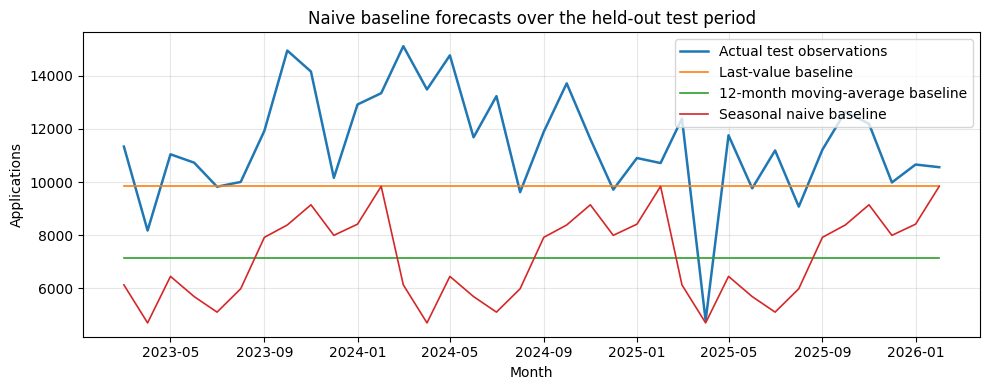

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    baseline_forecasts["date"],
    baseline_forecasts["actual_applications"],
    label="Actual test observations",
    linewidth=1.8,
)
ax.plot(
    baseline_forecasts["date"],
    baseline_forecasts["last_value_forecast"],
    label="Last-value baseline",
    linewidth=1.2,
)
ax.plot(
    baseline_forecasts["date"],
    baseline_forecasts["moving_average_12_month_forecast"],
    label="12-month moving-average baseline",
    linewidth=1.2,
)
ax.plot(
    baseline_forecasts["date"],
    baseline_forecasts["seasonal_naive_forecast"],
    label="Seasonal naive baseline",
    linewidth=1.2,
)
ax.set_title("Naive baseline forecasts over the held-out test period")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


The error table summarises baseline performance over the full held-out test period.


In [54]:
baseline_metrics = pd.DataFrame(
    [
        evaluate_forecast(
            baseline_forecasts["actual_applications"],
            baseline_forecasts["last_value_forecast"],
            "Last-value",
            label_column="Baseline",
        ),
        evaluate_forecast(
            baseline_forecasts["actual_applications"],
            baseline_forecasts["moving_average_12_month_forecast"],
            "12-month moving average",
            label_column="Baseline",
        ),
        evaluate_forecast(
            baseline_forecasts["actual_applications"],
            baseline_forecasts["seasonal_naive_forecast"],
            "Seasonal naive",
            label_column="Baseline",
        ),
    ]
)

display_metric_table(baseline_metrics)


,Baseline,MAE,RMSE
0,Last-value,2024.9,2570.0
1,12-month moving average,4409.4,4732.3
2,Seasonal naive,4277.9,4792.4


The last-value baseline performs best over the held-out test period, with the lowest MAE and RMSE among the three simple benchmarks. This means that, in this particular test period, simply carrying forward the February 2023 level gives a better average forecast than using the previous 12-month average or repeating the final observed seasonal pattern.

The 12-month moving-average and seasonal naive baselines both forecast values that are too low for much of the test period. This is visible in the plot: the held-out observations mostly sit above these two benchmark lines. The seasonal naive forecast repeats a within-year pattern, but because it repeats a lower training-period level, it misses the higher level seen in much of the test period.

This result should be interpreted cautiously. These are fixed-origin benchmark forecasts, not a recommended way to forecast 36 months ahead in real operations. In practice, even simple baselines would normally be updated as new monthly data became available. Here, the purpose is narrower: to create transparent, leakage-free benchmarks for judging whether SARIMA or SARIMAX models add value.

The first SARIMA model should therefore be assessed against a clear reference point: it needs to improve on the last-value baseline, not only on the weaker moving-average or seasonal naive baselines.


The next part will move from benchmark forecasts to SARIMA modelling. The baseline results above provide the reference point for judging whether a seasonal time-series model adds value.


# Part III - Building and selecting SARIMA models

## 7. First SARIMA model

We now move from benchmark forecasts to a first SARIMA model.

SARIMA stands for seasonal autoregressive integrated moving-average model. In practical terms, it uses past values, past forecast errors, differencing, and seasonal structure to model a time series. This makes it a useful first modelling step for a monthly series with changing levels and recurring within-year patterns.

This first model is deliberately simple. It is not the final model selection. It gives us an initial model-based benchmark before we compare a small set of alternative SARIMA specifications.

We use:

```text
SARIMA(1, 1, 1)(1, 1, 1, 12)
```

The non-seasonal part, `(1, 1, 1)`, allows for one autoregressive term, one order of differencing, and one moving-average term. The seasonal part, `(1, 1, 1, 12)`, applies the same basic idea at a 12-month seasonal cycle.

The model is fit on the training period only: January 2008 to February 2023. It then forecasts the held-out test period: March 2023 to February 2026.


In [55]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [56]:
training_series = train.set_index("date")["applications"].asfreq("MS")


We fit the first SARIMA model below.


In [57]:
first_sarima_model = SARIMAX(
    training_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

first_sarima_results = first_sarima_model.fit(disp=False)


The fitted model is summarised in a compact table.


In [58]:
first_sarima_model_info = make_model_info_table(
    "First SARIMA",
    (1, 1, 1),
    (1, 1, 1, 12),
    first_sarima_results,
    train,
    test,
)

first_sarima_model_info


,Model,Non-seasonal order,Seasonal order,Training period,Test period,AIC,BIC
0,First SARIMA,"(1, 1, 1)","(1, 1, 1, 12)",2008-01 to 2023-02,2023-03 to 2026-02,2595.5,2610.8


We now forecast the 36-month test period. The forecast is generated from the model fitted only on the training data.

The plot shows the observed applications in the test period, the SARIMA point forecast, and an 80% model-based confidence interval.


In [59]:
first_sarima_forecast = make_forecast_frame(
    first_sarima_results,
    test,
    forecast_column="sarima_forecast",
    lower_column="sarima_lower_80",
    upper_column="sarima_upper_80",
)


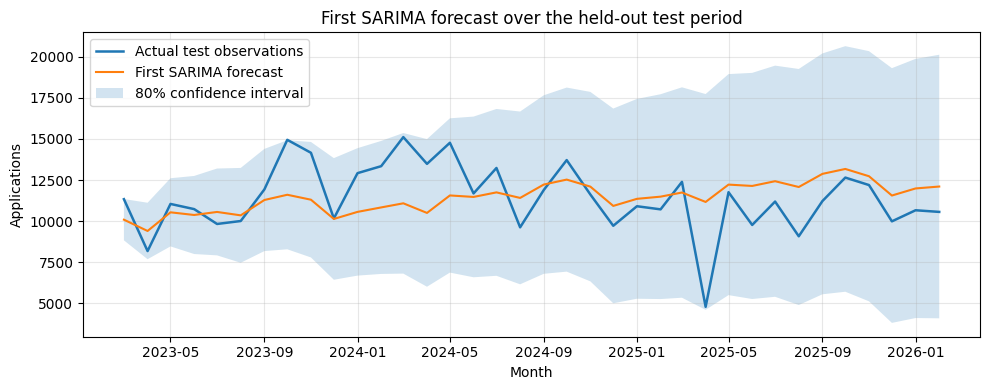

In [60]:
plot_forecast_with_interval(
    first_sarima_forecast,
    forecast_column="sarima_forecast",
    lower_column="sarima_lower_80",
    upper_column="sarima_upper_80",
    title="First SARIMA forecast over the held-out test period",
    forecast_label="First SARIMA forecast",
    grid_alpha=0.3,
)


The confidence interval should be interpreted cautiously. The shaded band shows model-based uncertainty under this SARIMA specification, not the full range of operational uncertainty. It does not capture all possible sources of uncertainty in asylum applications, such as policy change, access to procedures, administrative capacity, route changes, or sudden geopolitical shocks.

Because the SARIMA model is fitted as a continuous statistical model, the lower confidence bound may approach or fall below zero at longer horizons, even though application counts cannot be negative. This should be read as a limitation of the model-based interval, not as a literal negative-count forecast.

The final step is to compare this first SARIMA model with the naive baselines from the previous section.


In [61]:
first_sarima_metric = evaluate_forecast(
    first_sarima_forecast["actual_applications"],
    first_sarima_forecast["sarima_forecast"],
    "First SARIMA",
)

model_comparison_metrics = pd.concat(
    [
        baseline_metrics.rename(columns={"Baseline": "Baseline / model"}),
        pd.DataFrame([first_sarima_metric]),
    ],
    ignore_index=True,
)

display_metric_table(model_comparison_metrics)


,Baseline / model,MAE,RMSE
0,Last-value,2024.9,2570.0
1,12-month moving average,4409.4,4732.3
2,Seasonal naive,4277.9,4792.4
3,First SARIMA,1544.3,2029.3


The first SARIMA model improves on all three naive baselines over the held-out test period. Its MAE and RMSE are both lower than the last-value baseline, which was the strongest naive benchmark. This suggests that even this untuned SARIMA model adds value in the current evaluation setup.

The improvement should still be interpreted cautiously. The SARIMA forecast follows the broad level of the test period better than the naive baselines, but it remains smoother than the observed monthly series. It does not capture sharper month-to-month movements, including the pronounced dip in 2025.

The 80% confidence interval widens over the forecast horizon, showing that model-based uncertainty increases further away from the training period. However, this interval reflects uncertainty under the fitted SARIMA model only. It does not capture the full operational uncertainty around asylum applications.

The main takeaway is that SARIMA is a promising next step, but this first specification is only a starting point. The next section will test whether a small set of alternative SARIMA specifications improves model fit and held-out forecast performance.


## 8. SARIMA model selection

The first SARIMA model improved on the naive baselines, but it used only one manually chosen specification. SARIMA models require choices about the non-seasonal and seasonal components of the model. Rather than relying on one starting specification, we now compare a small set of plausible alternatives.

This is not an exhaustive search. The aim is to keep the search space limited, transparent, and computationally manageable. We vary only low-order SARIMA specifications and keep the seasonal period fixed at 12 months, because the data are monthly.

The grid search is run on the training period only. The held-out test period is still kept separate and will be used in the next section to evaluate the selected model.

The search space is:


In [62]:
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
seasonal_period = 12

total_sarima_candidates = (
    len(p_values)
    * len(d_values)
    * len(q_values)
    * len(P_values)
    * len(D_values)
    * len(Q_values)
)
assert total_sarima_candidates == 144

sarima_grid_definition = pd.DataFrame(
    [
        {"Parameter": "p", "Values": "0, 1, 2", "Meaning": "Non-seasonal autoregressive order"},
        {"Parameter": "d", "Values": "0, 1", "Meaning": "Non-seasonal differencing order"},
        {"Parameter": "q", "Values": "0, 1, 2", "Meaning": "Non-seasonal moving-average order"},
        {"Parameter": "P", "Values": "0, 1", "Meaning": "Seasonal autoregressive order"},
        {"Parameter": "D", "Values": "0, 1", "Meaning": "Seasonal differencing order"},
        {"Parameter": "Q", "Values": "0, 1", "Meaning": "Seasonal moving-average order"},
        {"Parameter": "s", "Values": "12", "Meaning": "Seasonal period in months"},
    ]
)

sarima_grid_definition


,Parameter,Values,Meaning
0,p,"0, 1, 2",Non-seasonal autoregressive order
1,d,"0, 1",Non-seasonal differencing order
2,q,"0, 1, 2",Non-seasonal moving-average order
3,P,"0, 1",Seasonal autoregressive order
4,D,"0, 1",Seasonal differencing order
5,Q,"0, 1",Seasonal moving-average order
6,s,12,Seasonal period in months


This gives 144 candidate SARIMA specifications:

```text
3 p-values x 2 d-values x 3 q-values x 2 P-values x 2 D-values x 2 Q-values = 144 candidates
```

Each candidate is fit to the training series and ranked by AIC. AIC is a model-selection criterion that balances fit and complexity: lower values are preferred, but AIC is still based on training-data fit. It does not by itself prove that a model will forecast the held-out test period better.


In [63]:
import itertools
import time
import warnings

training_series = train.set_index("date")["applications"].asfreq("MS")

sarima_grid_rows = []
grid_search_start = time.perf_counter()

for p, d, q, P, D, Q in itertools.product(
    p_values, d_values, q_values, P_values, D_values, Q_values
):
    order = (p, d, q)
    seasonal_order = (P, D, Q, seasonal_period)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            candidate_model = SARIMAX(
                training_series,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            candidate_results = candidate_model.fit(disp=False)

        mle_retvals = getattr(candidate_results, "mle_retvals", {}) or {}
        sarima_grid_rows.append(
            {
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": candidate_results.aic,
                "BIC": candidate_results.bic,
                "converged": bool(mle_retvals.get("converged", False)),
                "failure_reason": None,
            }
        )
    except Exception as exc:
        sarima_grid_rows.append(
            {
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": pd.NA,
                "BIC": pd.NA,
                "converged": False,
                "failure_reason": str(exc),
            }
        )

sarima_grid_runtime_seconds = time.perf_counter() - grid_search_start
sarima_grid_results = pd.DataFrame(sarima_grid_rows)

fitted_sarima_grid_results = sarima_grid_results[
    sarima_grid_results["failure_reason"].isna()
].copy()

best_sarima_aic = fitted_sarima_grid_results["AIC"].min()
fitted_sarima_grid_results["Delta AIC"] = (
    fitted_sarima_grid_results["AIC"] - best_sarima_aic
)

sarima_top5 = (
    fitted_sarima_grid_results.sort_values(["AIC", "BIC"])
    .head(5)
    .reset_index(drop=True)
)
sarima_top5.insert(0, "rank", sarima_top5.index + 1)

selected_sarima_specification = sarima_top5.head(1).copy()
selected_sarima_order = selected_sarima_specification.loc[0, "order"]
selected_sarima_seasonal_order = selected_sarima_specification.loc[0, "seasonal_order"]


The grid-search run is summarised below.


In [64]:
successful_sarima_fits = int(sarima_grid_results["failure_reason"].isna().sum())
failed_sarima_fits = int(sarima_grid_results["failure_reason"].notna().sum())

sarima_grid_summary = pd.DataFrame(
    [
        {
            "Total candidates": total_sarima_candidates,
            "Successful fits": successful_sarima_fits,
            "Failed fits": failed_sarima_fits,
            "Runtime seconds": round(sarima_grid_runtime_seconds, 1),
        }
    ]
)

sarima_grid_summary


,Total candidates,Successful fits,Failed fits,Runtime seconds
0,144,144,0,25.7


The tables report four model-selection fields. **AIC** and **BIC** are information criteria: both reward better fit and penalise unnecessary complexity, with lower values preferred. BIC penalises complexity more strongly than AIC. **Delta AIC** shows how far each candidate is from the lowest-AIC model in this grid; values close to zero mean that the candidates are very similar by AIC. **Converged** indicates whether the numerical fitting routine reported successful convergence.

We show only the five best fitted specifications by AIC.


In [65]:
sarima_top5_display = sarima_top5[
    ["rank", "order", "seasonal_order", "AIC", "Delta AIC", "BIC", "converged"]
].copy()

for column in ["AIC", "Delta AIC", "BIC"]:
    sarima_top5_display[column] = sarima_top5_display[column].round(1)

sarima_top5_display


,rank,order,seasonal_order,AIC,Delta AIC,BIC,converged
0,1,"(0, 1, 2)","(1, 1, 1, 12)",2579.2,0.0,2594.3,True
1,2,"(0, 1, 2)","(0, 1, 1, 12)",2579.3,0.2,2591.5,True
2,3,"(1, 1, 2)","(1, 1, 1, 12)",2580.9,1.7,2599.1,True
3,4,"(1, 1, 2)","(0, 1, 1, 12)",2581.1,2.0,2596.3,True
4,5,"(2, 1, 2)","(1, 1, 1, 12)",2586.9,7.8,2608.2,False


We also show the five weakest fitted specifications by AIC. This table is not used for selection, but it helps show the range of model fit across the limited search space.


In [66]:
sarima_worst5 = (
    fitted_sarima_grid_results.dropna(subset=["AIC", "BIC"])
    .sort_values(["AIC", "BIC"], ascending=[False, False])
    .head(5)
    .reset_index(drop=True)
)
sarima_worst5.insert(0, "worst_rank", sarima_worst5.index + 1)

sarima_worst5_display = sarima_worst5[
    [
        "worst_rank",
        "order",
        "seasonal_order",
        "AIC",
        "Delta AIC",
        "BIC",
        "converged",
    ]
].copy()

for column in ["AIC", "Delta AIC", "BIC"]:
    sarima_worst5_display[column] = sarima_worst5_display[column].round(1)

sarima_worst5_display


,worst_rank,order,seasonal_order,AIC,Delta AIC,BIC,converged
0,1,"(0, 0, 0)","(0, 0, 0, 12)",3629.6,1050.4,3632.8,True
1,2,"(0, 0, 1)","(0, 0, 0, 12)",3427.0,847.8,3433.4,True
2,3,"(0, 0, 2)","(0, 0, 0, 12)",3266.4,687.3,3276.0,True
3,4,"(0, 0, 0)","(0, 0, 1, 12)",3265.9,686.8,3272.2,True
4,5,"(0, 0, 0)","(1, 0, 0, 12)",3200.6,621.4,3206.8,True


The lowest-AIC specification is selected for held-out evaluation in the next section.


In [67]:
selected_sarima_specification_display = selected_sarima_specification[
    ["order", "seasonal_order", "AIC", "Delta AIC", "BIC", "converged"]
].copy()

for column in ["AIC", "Delta AIC", "BIC"]:
    selected_sarima_specification_display[column] = (
        selected_sarima_specification_display[column].round(1)
    )

selected_sarima_specification_display


,order,seasonal_order,AIC,Delta AIC,BIC,converged
0,"(0, 1, 2)","(1, 1, 1, 12)",2579.2,0.0,2594.3,True


The lowest-AIC specification in this limited grid search is SARIMA(0, 1, 2)(1, 1, 1, 12). It keeps first differencing and seasonal differencing, uses two non-seasonal moving-average terms, and includes seasonal autoregressive and moving-average terms at the 12-month cycle.

The top AIC results are close. The second-ranked model has a Delta AIC of only 0.2, and the third and fourth candidates are also within about 2 AIC points of the selected model. The selected specification is therefore the best candidate in this limited search, not the only reasonable choice.

The weakest models have much higher AIC values, showing that some SARIMA specifications fit the training series much less well than the leading candidates. All 144 candidates returned fitted results, with no failed fits. Six fitted models did not converge, but the selected model did.


The selected SARIMA specification is a reasonable candidate to carry forward. The next section evaluates whether it improves held-out forecast performance compared with the naive baselines and the first SARIMA model.


## 9. Selected SARIMA diagnostics and test-set evaluation

The previous section selected SARIMA(0, 1, 2)(1, 1, 1, 12) as the lowest-AIC specification within the limited grid search.

We now use that selected specification in two steps.

First, we briefly inspect the fitted model diagnostics on the training period. This is a statistical check of the model residuals, not the main evaluation criterion.

Second, we forecast the held-out test period and compare the selected SARIMA model against the naive baselines and the first SARIMA model.


### 9.1 Fit the selected SARIMA model

The selected SARIMA specification is fitted on the training series only.


In [68]:
selected_sarima_model = SARIMAX(
    training_series,
    order=selected_sarima_order,
    seasonal_order=selected_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
selected_sarima_results = selected_sarima_model.fit(disp=False)


The fitted selected model is summarised below.


In [69]:
selected_sarima_model_info = make_model_info_table(
    "Selected SARIMA",
    selected_sarima_order,
    selected_sarima_seasonal_order,
    selected_sarima_results,
    train,
    test,
)

selected_sarima_model_info


,Model,Non-seasonal order,Seasonal order,Training period,Test period,AIC,BIC
0,Selected SARIMA,"(0, 1, 2)","(1, 1, 1, 12)",2008-01 to 2023-02,2023-03 to 2026-02,2579.2,2594.3


### 9.2 Brief residual diagnostics

Before evaluating the selected model on the held-out test period, we briefly inspect its residual diagnostics.

The diagnostic plot gives a compact view of residual behaviour, including residuals over time, residual distribution, a Q-Q plot, and residual autocorrelation. This helps identify obvious problems, such as remaining time dependence or strong departures from the model assumptions.


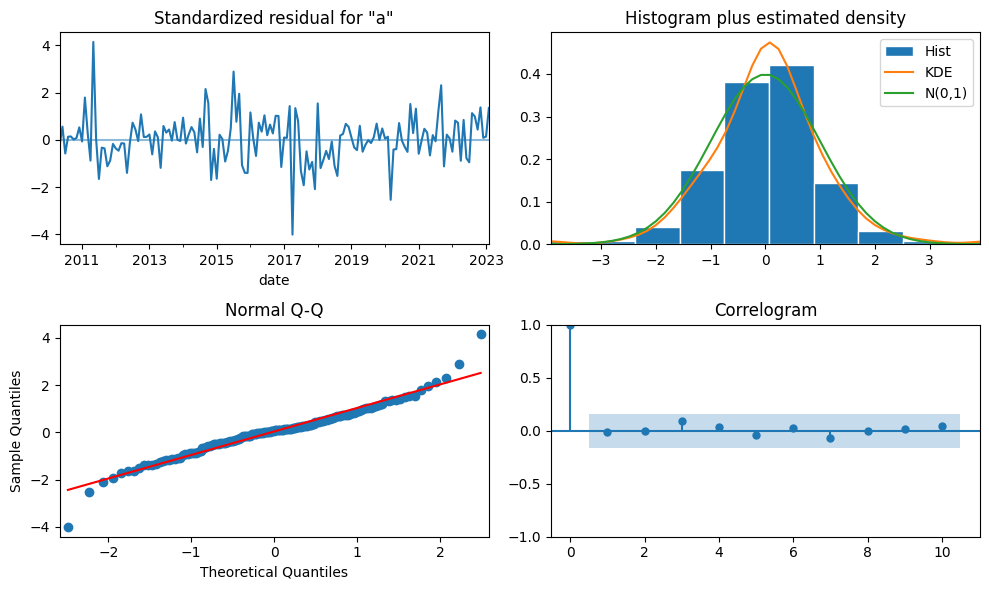

In [70]:
selected_sarima_results.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()


The diagnostic plots do not show obvious remaining autocorrelation. The residual correlogram is mostly within the confidence band after lag zero, suggesting that the selected SARIMA model has captured much of the remaining time dependence in the training series.

The residuals are mostly centred around zero, but there are several large spikes. The histogram is roughly centred, while the Q-Q plot follows the reference line through the middle but departs in the tails. This suggests that the residuals are not perfectly normal and that some extreme months are not fully captured by the model.

These diagnostics are useful checks, but they are not the main evaluation criterion. The more important question for this notebook is whether the selected SARIMA improves forecast performance on the held-out test period.


### 9.3 Forecast the held-out test period

We now forecast the full held-out test period: March 2023 to February 2026.

The forecast is generated from the selected SARIMA model fitted only on the training data.


In [71]:
selected_sarima_forecast = make_forecast_frame(
    selected_sarima_results,
    test,
    forecast_column="selected_sarima_forecast",
    lower_column="selected_sarima_lower_80",
    upper_column="selected_sarima_upper_80",
)


The plot compares the selected SARIMA forecast with the actual held-out test observations.


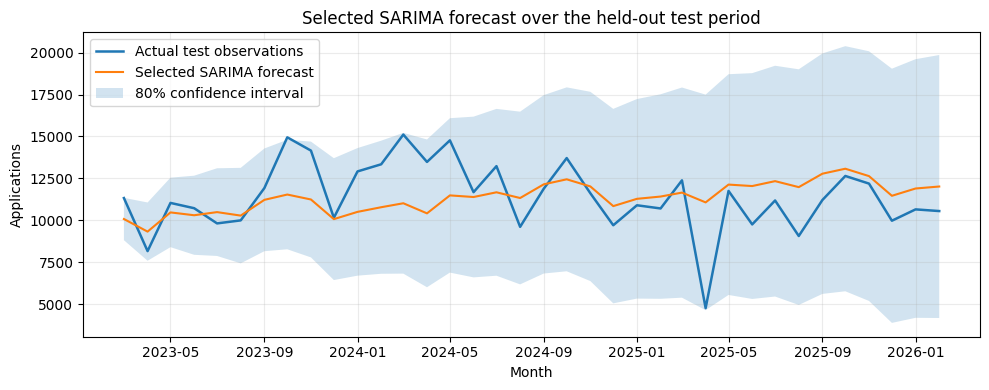

In [72]:
plot_forecast_with_interval(
    selected_sarima_forecast,
    forecast_column="selected_sarima_forecast",
    lower_column="selected_sarima_lower_80",
    upper_column="selected_sarima_upper_80",
    title="Selected SARIMA forecast over the held-out test period",
    forecast_label="Selected SARIMA forecast",
)


As before, the confidence interval is model-based. It reflects uncertainty under the selected SARIMA model, not the full operational uncertainty around future asylum applications.


### 9.4 Compare forecast accuracy

The final step is to compare the selected SARIMA model against the earlier benchmarks.

We use the same evaluation metrics as before:

- **MAE**, the average absolute forecast error in monthly applications;
- **RMSE**, which gives more weight to larger forecast misses.


In [73]:
selected_sarima_metric = evaluate_forecast(
    selected_sarima_forecast["actual_applications"],
    selected_sarima_forecast["selected_sarima_forecast"],
    "Selected SARIMA",
)


In [74]:
selected_model_comparison_metrics = pd.concat(
    [
        model_comparison_metrics,
        pd.DataFrame([selected_sarima_metric]),
    ],
    ignore_index=True,
)

display_metric_table(selected_model_comparison_metrics)


,Baseline / model,MAE,RMSE
0,Last-value,2024.9,2570.0
1,12-month moving average,4409.4,4732.3
2,Seasonal naive,4277.9,4792.4
3,First SARIMA,1544.3,2029.3
4,Selected SARIMA,1526.4,2020.6


The selected SARIMA model performs slightly better than the first SARIMA model on the held-out test period. Its MAE falls from **1544.3** to **1526.4**, and its RMSE falls from **2029.3** to **2020.6**. This is an improvement, but a modest one.

The selected SARIMA also performs clearly better than the strongest naive baseline, the last-value forecast. Compared with that baseline, it reduces MAE by about **498 applications** and RMSE by about **549 applications**.

The forecast plot shows that the selected SARIMA follows the broad level of the test period reasonably well, but it remains smoother than the observed series. It does not fully capture sharp monthly movements, especially the pronounced dip in 2025. The 80% confidence interval covers much of the test-period movement, but it is wide and should still be read as model-based uncertainty, not full operational uncertainty.

Overall, the selected SARIMA is a useful improvement over the benchmark forecasts, but the gains over the first SARIMA are limited. The next part asks whether adding descriptive event-period indicators through SARIMAX improves the forecast further.


## 10. SARIMAX with descriptive event-period indicators

The selected SARIMA model uses the past behaviour of the application series, including seasonal structure, to forecast the held-out test period. It does not include any additional information about historically unusual periods.

In this section, we add a small number of descriptive event-period indicators. These indicators mark broad historical periods that may have affected the level, timing, or administrative recording of first-time asylum applications in Italy.

The indicators are not causal estimates. They should not be read as measuring the effect of a single event, policy, agreement, route-control measure, or administrative decision. Their purpose is more limited: they allow the SARIMAX model to distinguish a few historically unusual periods from the regular time-series and seasonal structure.


We use three descriptive event-period indicators:

**`european_refugee_crisis` - 2015-01 to 2016-12**  
This indicator marks the 2015-2016 European refugee crisis, when asylum applications across Europe reached exceptional levels. It is included as a broad regional marker, not as an Italy-specific causal explanation.

**`central_med_route_shift` - 2017-07 to 2019-12**  
This indicator marks a period of changed Central Mediterranean route dynamics after mid-2017, including increased cooperation between Italian and Libyan authorities, more interceptions, reduced successful crossings to Italy, and a changed rescue/disembarkation environment. It is not interpreted as the causal effect of one agreement or policy, such as the Italy-Libya Memorandum of Understanding.

**`covid_disruption` - 2020-03 to 2021-12**  
This indicator marks the COVID-19 disruption period, when mobility restrictions, border measures, and administrative interruptions plausibly affected access to the asylum procedure and, consequently, the observed number of asylum applications.


The indicator columns are added to a copy of the main application table. The original `applications` dataframe is left unchanged.


In [75]:
applications_with_indicators = applications.copy()

european_refugee_crisis_mask = (
    (applications_with_indicators["date"] >= pd.Timestamp("2015-01-01"))
    & (applications_with_indicators["date"] <= pd.Timestamp("2016-12-01"))
)
applications_with_indicators["european_refugee_crisis"] = (
    european_refugee_crisis_mask.astype(int)
)

central_med_route_shift_mask = (
    (applications_with_indicators["date"] >= pd.Timestamp("2017-07-01"))
    & (applications_with_indicators["date"] <= pd.Timestamp("2019-12-01"))
)
applications_with_indicators["central_med_route_shift"] = (
    central_med_route_shift_mask.astype(int)
)

covid_disruption_mask = (
    (applications_with_indicators["date"] >= pd.Timestamp("2020-03-01"))
    & (applications_with_indicators["date"] <= pd.Timestamp("2021-12-01"))
)
applications_with_indicators["covid_disruption"] = covid_disruption_mask.astype(int)



In [76]:
assert int(applications_with_indicators["european_refugee_crisis"].sum()) == 24
assert int(applications_with_indicators["central_med_route_shift"].sum()) == 30
assert int(applications_with_indicators["covid_disruption"].sum()) == 22


The plot below shows where the three descriptive event periods fall in the monthly application series.


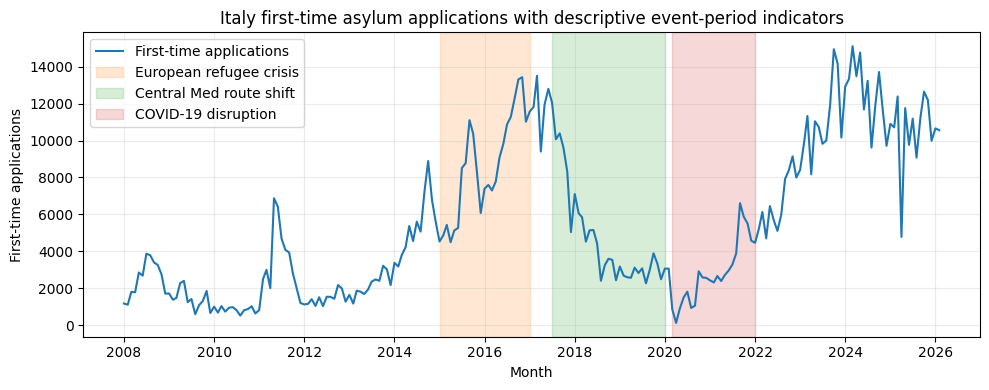

In [77]:
indicator_plot_periods = [
    {
        "label": "European refugee crisis",
        "start": pd.Timestamp("2015-01-01"),
        "end": pd.Timestamp("2016-12-01"),
        "color": "tab:orange",
    },
    {
        "label": "Central Med route shift",
        "start": pd.Timestamp("2017-07-01"),
        "end": pd.Timestamp("2019-12-01"),
        "color": "tab:green",
    },
    {
        "label": "COVID-19 disruption",
        "start": pd.Timestamp("2020-03-01"),
        "end": pd.Timestamp("2021-12-01"),
        "color": "tab:red",
    },
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    applications_with_indicators["date"],
    applications_with_indicators["applications"],
    color="tab:blue",
    linewidth=1.5,
    label="First-time applications",
)

for period in indicator_plot_periods:
    ax.axvspan(
        period["start"],
        period["end"] + pd.offsets.MonthEnd(0),
        color=period["color"],
        alpha=0.18,
        label=period["label"],
    )

ax.set_title(
    "Italy first-time asylum applications with descriptive event-period indicators"
)
ax.set_xlabel("Month")
ax.set_ylabel("First-time applications")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)

plt.tight_layout()


The indicators do not attempt to explain every movement in the series. They mark only three broad periods that are historically relevant and defined before model fitting.

This is important for model discipline. We do not add a dedicated post-2022 indicator at this stage, even though the held-out test period contains a high-application phase. Adding such an indicator would risk building the test-period pattern into the model by hand. Instead, the SARIMA and SARIMAX models should be evaluated on whether they can forecast the held-out period without being given a special post-2022 marker.

In the next section, these indicators will be used as exogenous variables in a SARIMAX model. The model will still use the selected SARIMA structure from the previous section, but it will also be allowed to adjust its fitted level during the three marked periods.
